# Financial Returns Prediction with LSTM (MLX)

This notebook mirrors the XGBoost workflow (`513_financial_xgboost.ipynb`) but trains sequence models using **MLX** (Apple Silicon). It keeps the same data prep and feature definitions so you can compare models side-by-side.

> Requires the MLX package (Apple Silicon). Install if needed: `pip install mlx` (and optionally `pip install mlx-lm`).

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx
import mlx.nn as nn
from mlx.optimizers import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window (same as XGBoost notebook)
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

np.random.seed(42)
mx.random.seed(42)


## 1. Load and Prepare Data

In [2]:

# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

if "Date_" not in df_raw.columns:
    raise KeyError("Expected a 'Date_' column in the market data file.")

# Parse dates and sort
df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
df_raw = df_raw.sort_values("Date_").set_index("Date_")

# Rename columns to simpler names (matches XGBoost notebook)
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business-day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)
price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

returns = returns.dropna().loc[START_DATE:END_DATE]

# Load EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"Data window: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Columns: {returns.columns.tolist()}")


Data window: 2025-01-01 to 2025-05-30
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


## 2. Feature Engineering

**Variables of Interest:** EPI and EPI_weighted (contemporaneous + multiple lags)  
**Control Variables:** FX rates, oil, interest rates, lagged returns, volatility

In [32]:
# Configuration
MAX_EPI_LAG = 5  # Test EPI lags from 1 to 5
MAX_RETURN_LAG = 3  # Lagged returns for controls

data = returns.copy()

# =============================================================================
# CONTROL VARIABLES (baseline features)
# =============================================================================

# 1. Lagged asset returns
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, MAX_RETURN_LAG + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# 2. Rolling volatility
for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

# =============================================================================
# VARIABLES OF INTEREST: EPI and EPI_weighted with multiple lags
# =============================================================================

# Contemporaneous EPI (t=0)
# Already in data: 'epi', 'epi_weighted'

# Lagged EPI (t-1 to t-MAX_EPI_LAG)
for lag in range(1, MAX_EPI_LAG + 1):
    data[f'epi_l{lag}'] = data['epi'].shift(lag)
    data[f'epi_weighted_l{lag}'] = data['epi_weighted'].shift(lag)

# Asymmetric effects (positive vs negative sentiment)
data['epi_pos'] = np.maximum(data['epi'], 0)
data['epi_neg'] = np.minimum(data['epi'], 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

# Rolling statistics
data['epi_ma5'] = data['epi'].rolling(5).mean()
data['epi_std5'] = data['epi'].rolling(5).std()
data['epi_weighted_ma5'] = data['epi_weighted'].rolling(5).mean()
data['epi_weighted_std5'] = data['epi_weighted'].rolling(5).std()

data = data.dropna()

# Print summary
print(f"Data shape: {data.shape}")
print(f"\n{'='*60}")
print("VARIABLE ORGANIZATION")
print(f"{'='*60}")
print(f"\nCONTROL VARIABLES:")
print(f"  - Macro controls: {['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']}")
print(f"  - Lagged returns: {[f'r_*_l{i}' for i in range(1, MAX_RETURN_LAG+1)]}")
print(f"  - Volatility: r_*_vol5")
print(f"\nVARIABLES OF INTEREST (EPI):")
print(f"  - Contemporaneous: epi, epi_weighted")
print(f"  - Lags 1-{MAX_EPI_LAG}: epi_l1..l{MAX_EPI_LAG}, epi_weighted_l1..l{MAX_EPI_LAG}")
print(f"  - Asymmetric: epi_pos, epi_neg, epi_weighted_pos, epi_weighted_neg")
print(f"  - Rolling: epi_ma5, epi_std5, epi_weighted_ma5, epi_weighted_std5")

Data shape: (103, 60)

VARIABLE ORGANIZATION

CONTROL VARIABLES:
  - Macro controls: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
  - Lagged returns: ['r_*_l1', 'r_*_l2', 'r_*_l3']
  - Volatility: r_*_vol5

VARIABLES OF INTEREST (EPI):
  - Contemporaneous: epi, epi_weighted
  - Lags 1-5: epi_l1..l5, epi_weighted_l1..l5
  - Asymmetric: epi_pos, epi_neg, epi_weighted_pos, epi_weighted_neg
  - Rolling: epi_ma5, epi_std5, epi_weighted_ma5, epi_weighted_std5


## 3. Model Specifications

**Research Design:**
- **Baseline**: Control variables only (no EPI)
- **EPI Models**: Baseline + EPI/EPI_weighted at different lags
- **Goal**: Test if EPI variables improve prediction over controls

In [33]:
# =============================================================================
# CONTROL VARIABLES (used in all models)
# =============================================================================
macro_controls = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

def get_control_features(asset: str) -> list:
    """Get baseline control features (no EPI)."""
    # Lagged own returns
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, MAX_RETURN_LAG + 1)]
    # Cross-asset lagged returns
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]
    # Volatility
    vol_cols = [f"{asset}_vol5"]
    
    return lag_cols + cross_cols + macro_controls + vol_cols


# =============================================================================
# EPI VARIABLE CONFIGURATIONS (Variables of Interest)
# =============================================================================

def get_epi_features(epi_type: str, lag_config: str) -> list:
    """
    Get EPI features based on type and lag configuration.
    
    Args:
        epi_type: 'epi' or 'epi_weighted'
        lag_config: 
            - 'l0': contemporaneous only
            - 'l1': lag 1 only
            - 'l2': lag 2 only
            - 'l3': lag 3 only
            - 'l0-1': contemporaneous + lag 1
            - 'l0-3': contemporaneous + lags 1-3
            - 'l1-3': lags 1-3 (no contemporaneous)
            - 'l0-5': contemporaneous + lags 1-5
            - 'full': all EPI features (lags + asymmetric + rolling)
    """
    features = []
    
    if lag_config == 'l0':
        features = [epi_type]
    elif lag_config == 'l1':
        features = [f'{epi_type}_l1']
    elif lag_config == 'l2':
        features = [f'{epi_type}_l2']
    elif lag_config == 'l3':
        features = [f'{epi_type}_l3']
    elif lag_config == 'l0-1':
        features = [epi_type, f'{epi_type}_l1']
    elif lag_config == 'l0-3':
        features = [epi_type] + [f'{epi_type}_l{i}' for i in range(1, 4)]
    elif lag_config == 'l1-3':
        features = [f'{epi_type}_l{i}' for i in range(1, 4)]
    elif lag_config == 'l0-5':
        features = [epi_type] + [f'{epi_type}_l{i}' for i in range(1, 6)]
    elif lag_config == 'full':
        features = (
            [epi_type] + 
            [f'{epi_type}_l{i}' for i in range(1, 4)] +
            [f'{epi_type}_pos', f'{epi_type}_neg'] +
            [f'{epi_type}_ma5', f'{epi_type}_std5']
        )
    else:
        raise ValueError(f"Unknown lag_config: {lag_config}")
    
    return features


def get_feature_cols(asset: str, model_type: str = "baseline") -> list:
    """
    Get all features for a model specification.
    
    Model types:
        - baseline: controls only (no EPI)
        - epi_l0, epi_l1, epi_l2, epi_l3: single lag
        - epi_l0-1, epi_l0-3, epi_l1-3, epi_l0-5: multiple lags
        - epi_full: all EPI features
        - epi_weighted_*: same patterns for weighted EPI
    """
    controls = get_control_features(asset)
    
    if model_type == "baseline":
        return controls
    
    # Parse model type: epi_l0, epi_weighted_l0-3, etc.
    if model_type.startswith("epi_weighted"):
        epi_type = "epi_weighted"
        lag_config = model_type.replace("epi_weighted_", "")
    elif model_type.startswith("epi"):
        epi_type = "epi"
        lag_config = model_type.replace("epi_", "")
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    epi_features = get_epi_features(epi_type, lag_config)
    return controls + epi_features


# =============================================================================
# Define model specifications to test
# =============================================================================

MODEL_SPECS = {
    # Baseline (controls only)
    "baseline": "Controls only (no EPI)",
    
    # EPI: Test individual lags
    "epi_l0": "EPI contemporaneous (t)",
    "epi_l1": "EPI lag 1 (t-1)",
    "epi_l2": "EPI lag 2 (t-2)", 
    "epi_l3": "EPI lag 3 (t-3)",
    
    # EPI: Test cumulative lags
    "epi_l0-1": "EPI t + t-1",
    "epi_l0-3": "EPI t + t-1 to t-3",
    "epi_l1-3": "EPI t-1 to t-3 (no contemp.)",
    
    # EPI weighted: Test individual lags
    "epi_weighted_l0": "EPI_w contemporaneous (t)",
    "epi_weighted_l1": "EPI_w lag 1 (t-1)",
    "epi_weighted_l2": "EPI_w lag 2 (t-2)",
    "epi_weighted_l3": "EPI_w lag 3 (t-3)",
    
    # EPI weighted: Test cumulative lags
    "epi_weighted_l0-1": "EPI_w t + t-1",
    "epi_weighted_l0-3": "EPI_w t + t-1 to t-3",
    "epi_weighted_l1-3": "EPI_w t-1 to t-3 (no contemp.)",
}

# Print model specifications
print("=" * 70)
print("MODEL SPECIFICATIONS")
print("=" * 70)
for model, desc in MODEL_SPECS.items():
    n_epi = len(get_feature_cols("r_btc", model)) - len(get_control_features("r_btc"))
    print(f"  {model:25s} | {desc:35s} | +{n_epi} EPI vars")

MODEL SPECIFICATIONS
  baseline                  | Controls only (no EPI)              | +0 EPI vars
  epi_l0                    | EPI contemporaneous (t)             | +1 EPI vars
  epi_l1                    | EPI lag 1 (t-1)                     | +1 EPI vars
  epi_l2                    | EPI lag 2 (t-2)                     | +1 EPI vars
  epi_l3                    | EPI lag 3 (t-3)                     | +1 EPI vars
  epi_l0-1                  | EPI t + t-1                         | +2 EPI vars
  epi_l0-3                  | EPI t + t-1 to t-3                  | +4 EPI vars
  epi_l1-3                  | EPI t-1 to t-3 (no contemp.)        | +3 EPI vars
  epi_weighted_l0           | EPI_w contemporaneous (t)           | +1 EPI vars
  epi_weighted_l1           | EPI_w lag 1 (t-1)                   | +1 EPI vars
  epi_weighted_l2           | EPI_w lag 2 (t-2)                   | +1 EPI vars
  epi_weighted_l3           | EPI_w lag 3 (t-3)                   | +1 EPI vars
  epi_weighted_l0-1

## 4. MLX LSTM helpers (sequence builder, model, training loop)

In [17]:
from typing import Dict, List, Tuple, Optional
import copy
import mlx.utils


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int, index: pd.Index):
    X_seq, y_seq, seq_dates = [], [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
        seq_dates.append(index[i])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        pd.Index(seq_dates),
    )


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> Dict[str, float]:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    # Handle zero returns for directional accuracy
    mask = actuals != 0
    if mask.sum() > 0:
        dir_acc = np.mean(np.sign(actuals[mask]) == np.sign(preds[mask])) * 100
    else:
        dir_acc = 50.0
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc}


def copy_weights(weights):
    """Deep copy model weights (nested dict of arrays)."""
    return mlx.utils.tree_map(lambda x: mx.array(x), weights)


class TemporalAttention(nn.Module):
    """Simple attention over timesteps to focus on important periods."""
    
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def __call__(self, x):
        # x: (batch, seq_len, hidden)
        scores = self.attention(x)  # (batch, seq_len, 1)
        weights = mx.softmax(scores, axis=1)
        # Weighted sum over timesteps
        context = mx.sum(x * weights, axis=1)  # (batch, hidden)
        return context, weights


class ImprovedLSTMRegressor(nn.Module):
    """Enhanced LSTM with attention, layer norm, and residual connections."""

    def __init__(
        self, 
        input_size: int, 
        hidden_size: int = 64, 
        num_layers: int = 2, 
        dropout: float = 0.2,
        use_attention: bool = True,
        use_layer_norm: bool = True,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout
        self.use_attention = use_attention
        self.use_layer_norm = use_layer_norm
        
        # Input projection for residual
        self.input_proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else None
        
        # Stack LSTM layers
        self.lstm_layers = []
        self.layer_norms = [] if use_layer_norm else None
        
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(layer_input_size, hidden_size))
            if use_layer_norm:
                self.layer_norms.append(nn.LayerNorm(hidden_size))
        
        # Dropout
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        
        # Attention mechanism
        self.attention = TemporalAttention(hidden_size) if use_attention else None
        
        # Output head with extra hidden layer
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)

    def __call__(self, x):
        # x: (batch, seq_len, features)
        batch_size, seq_len, _ = x.shape
        
        # MLX LSTM expects (seq_len, batch, features)
        out = mx.swapaxes(x, 0, 1)
        
        for i, lstm in enumerate(self.lstm_layers):
            lstm_out, _ = lstm(out)
            
            # Layer normalization
            if self.use_layer_norm:
                # Swap to (batch, seq, hidden) for layer norm
                lstm_out_t = mx.swapaxes(lstm_out, 0, 1)
                lstm_out_t = self.layer_norms[i](lstm_out_t)
                lstm_out = mx.swapaxes(lstm_out_t, 0, 1)
            
            # Residual connection (after first layer)
            if i > 0:
                lstm_out = lstm_out + out
            
            # Dropout between layers
            if self.dropout is not None and i < self.num_layers - 1:
                lstm_out = self.dropout(lstm_out)
            
            out = lstm_out
        
        # Swap back: (seq, batch, hidden) -> (batch, seq, hidden)
        out = mx.swapaxes(out, 0, 1)
        
        # Attention or last timestep
        if self.use_attention:
            context, _ = self.attention(out)
        else:
            context = out[:, -1, :]
        
        # Two-layer head with GELU activation
        h = nn.gelu(self.fc1(context))
        if self.dropout is not None:
            h = self.dropout(h)
        return self.fc2(h).squeeze(-1)


def get_lr_schedule(epoch: int, total_epochs: int, base_lr: float, warmup_epochs: int = 5) -> float:
    """Cosine annealing with linear warmup."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


def clip_gradients(grads, max_norm: float = 1.0):
    """Clip gradients by global norm."""
    def compute_norm(g):
        if isinstance(g, mx.array):
            return float(mx.sum(g * g))
        return 0.0
    
    total_norm_sq = mlx.utils.tree_reduce(lambda acc, g: acc + compute_norm(g), grads, 0.0)
    total_norm = np.sqrt(total_norm_sq)
    
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        grads = mlx.utils.tree_map(lambda g: g * scale if isinstance(g, mx.array) else g, grads)
    
    return grads


def train_lstm_model(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    seq_len: int = 15,  # Reduced for small dataset
    hidden_size: int = 32,  # Smaller to reduce overfitting
    num_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
    epochs: int = 100,
    batch_size: int = 16,  # Smaller batches
    patience: int = 15,  # More patience
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    use_attention: bool = True,
    use_layer_norm: bool = True,
    grad_clip: float = 1.0,
    verbose: bool = True,
):
    df_fit = df.dropna(subset=[asset] + feature_cols)
    if len(df_fit) <= seq_len + 10:
        return {"error": "Insufficient data after lagging for LSTM."}

    # Time-based split
    train_end = int(len(df_fit) * train_ratio)
    val_end = int(len(df_fit) * (train_ratio + val_ratio))

    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)

    # Robust scaling (less sensitive to outliers)
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)

    X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)

    train_cut = max(train_end - seq_len, 1)
    val_cut = max(val_end - seq_len, train_cut + 1)

    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_val, y_val = X_seq[train_cut:val_cut], y_seq[train_cut:val_cut]
    X_test, y_test = X_seq[val_cut:], y_seq[val_cut:]
    date_test = seq_dates[val_cut:]

    if len(X_test) == 0:
        return {"error": "Test window empty; reduce seq_len or adjust split."}

    # Data augmentation: add small noise to training data
    X_train_aug = X_train + np.random.normal(0, 0.01, X_train.shape).astype(np.float32)
    X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
    y_train_combined = np.concatenate([y_train, y_train], axis=0)

    model = ImprovedLSTMRegressor(
        X_train.shape[-1], 
        hidden_size=hidden_size, 
        num_layers=num_layers, 
        dropout=dropout,
        use_attention=use_attention,
        use_layer_norm=use_layer_norm,
    )
    
    # Use AdamW with weight decay
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-3)

    def loss_fn(model, xb, yb):
        preds = model(xb)
        mse = mx.mean((preds - yb) ** 2)
        return mse

    loss_and_grad = nn.value_and_grad(model, loss_fn)

    best_weights = None
    best_val = np.inf
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Update learning rate
        current_lr = get_lr_schedule(epoch, epochs, learning_rate)
        optimizer.learning_rate = current_lr
        
        # Training with shuffled augmented data
        perm = np.random.permutation(len(X_train_combined))
        epoch_loss = 0.0
        n_batches = 0
        
        for start in range(0, len(perm), batch_size):
            idx = perm[start : start + batch_size]
            xb = mx.array(X_train_combined[idx])
            yb = mx.array(y_train_combined[idx])
            
            loss, grads = loss_and_grad(model, xb, yb)
            
            # Gradient clipping
            if grad_clip > 0:
                grads = clip_gradients(grads, grad_clip)
            
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
            
            epoch_loss += float(loss)
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        if len(X_val) > 0:
            val_pred = model(mx.array(X_val))
            val_loss = float(mx.mean((val_pred - mx.array(y_val)) ** 2))
        else:
            val_loss = avg_train_loss
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} | LR {current_lr:.6f} | Train {avg_train_loss:.6f} | Val {val_loss:.6f}")

        # Early stopping with patience
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_weights = copy_weights(model.parameters())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    if best_weights is not None:
        model.update(best_weights)

    # Evaluation
    test_pred = model(mx.array(X_test))
    test_pred_np = np.asarray(test_pred).reshape(-1)
    metrics = compute_metrics(y_test, test_pred_np)

    preds_series = pd.Series(test_pred_np, index=date_test)
    actual_series = pd.Series(y_test, index=date_test)

    return {
        **metrics,
        "predictions": preds_series,
        "actuals": actual_series,
        "val_loss": best_val,
        "feature_cols": feature_cols,
        "seq_len": seq_len,
        "scaler": scaler,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    }

## 4b. Walk-Forward Validation & Feature Selection

Walk-forward validation provides robust evaluation by simulating real trading conditions - training on past data and testing on future data repeatedly.

In [53]:
def walk_forward_validation(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_splits: int = 5,
    min_train_size: int = 40,
    test_size: int = 10,
    seq_len: int = 10,
    hidden_size: int = 32,
    num_layers: int = 2,
    dropout: float = 0.3,
    learning_rate: float = 5e-4,
    weight_decay: float = 1e-3,  # Added weight_decay parameter
    epochs: int = 100,
    batch_size: int = 8,
    patience: int = 15,
    verbose: bool = False,
) -> Dict:
    """
    Walk-forward (expanding window) cross-validation for time series.
    
    Each fold:
    - Train on all data up to split point
    - Test on next `test_size` observations
    - Move forward and repeat
    
    Returns aggregated metrics across all folds.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    n_samples = len(df_fit)
    
    if n_samples < min_train_size + test_size + seq_len:
        return {"error": "Insufficient data for walk-forward validation"}
    
    # Calculate split points
    available_for_test = n_samples - min_train_size - seq_len
    actual_splits = min(n_splits, available_for_test // test_size)
    
    if actual_splits < 2:
        return {"error": f"Can only do {actual_splits} splits, need at least 2"}
    
    all_preds = []
    all_actuals = []
    all_dates = []
    fold_metrics = []
    
    for fold in range(actual_splits):
        # Expanding window: train size grows with each fold
        train_end_idx = min_train_size + fold * test_size
        test_start_idx = train_end_idx
        test_end_idx = min(test_start_idx + test_size, n_samples)
        
        if test_end_idx <= test_start_idx:
            break
            
        # Extract fold data
        features = df_fit[feature_cols].values.astype(np.float32)
        target = df_fit[asset].values.astype(np.float32)
        
        # Fit scaler on training data only
        scaler = StandardScaler()
        scaler.fit(features[:train_end_idx])
        features_scaled = scaler.transform(features)
        
        # Create sequences
        X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)
        
        # Adjust indices for sequences
        train_cut = max(train_end_idx - seq_len, 1)
        test_start = train_cut
        test_end = min(test_end_idx - seq_len, len(X_seq))
        
        if test_end <= test_start:
            continue
            
        X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
        X_test, y_test = X_seq[test_start:test_end], y_seq[test_start:test_end]
        date_test = seq_dates[test_start:test_end]
        
        if len(X_train) < 10 or len(X_test) == 0:
            continue
        
        # Train model for this fold
        model = ImprovedLSTMRegressor(
            X_train.shape[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            use_attention=False,      # Disable attention (simpler model)
            use_layer_norm=True,
        )
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
        
        def loss_fn(model, xb, yb):
            return mx.mean((model(xb) - yb) ** 2)
        
        loss_and_grad = nn.value_and_grad(model, loss_fn)
        
        best_weights = None
        best_loss = np.inf
        wait = 0
        
        # Use last 20% of training as validation
        val_size = max(int(len(X_train) * 0.2), 1)
        X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
        X_vl, y_vl = X_train[-val_size:], y_train[-val_size:]
        
        for epoch in range(epochs):
            current_lr = get_lr_schedule(epoch, epochs, learning_rate)
            optimizer.learning_rate = current_lr
            
            perm = np.random.permutation(len(X_tr))
            for start in range(0, len(perm), batch_size):
                idx = perm[start:start + batch_size]
                xb, yb = mx.array(X_tr[idx]), mx.array(y_tr[idx])
                loss, grads = loss_and_grad(model, xb, yb)
                grads = clip_gradients(grads, 1.0)
                optimizer.update(model, grads)
                mx.eval(model.parameters(), optimizer.state)
            
            # Validation
            val_pred = model(mx.array(X_vl))
            val_loss = float(mx.mean((val_pred - mx.array(y_vl)) ** 2))
            
            if val_loss < best_loss - 1e-7:
                best_loss = val_loss
                best_weights = copy_weights(model.parameters())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break
        
        if best_weights is not None:
            model.update(best_weights)
        
        # Predict on test fold
        test_pred = model(mx.array(X_test))
        test_pred_np = np.asarray(test_pred).reshape(-1)
        
        all_preds.extend(test_pred_np)
        all_actuals.extend(y_test)
        all_dates.extend(date_test)
        
        fold_metric = compute_metrics(y_test, test_pred_np)
        fold_metrics.append(fold_metric)
        
        if verbose:
            print(f"Fold {fold+1}/{actual_splits}: RMSE={fold_metric['rmse']:.5f}, "
                  f"DirAcc={fold_metric['dir_acc']:.1f}%, n_test={len(y_test)}")
    
    if not all_preds:
        return {"error": "No successful folds"}
    
    # Aggregate metrics
    all_preds = np.array(all_preds)
    all_actuals = np.array(all_actuals)
    overall_metrics = compute_metrics(all_actuals, all_preds)
    
    # Calculate std across folds
    rmse_std = np.std([f['rmse'] for f in fold_metrics])
    dir_acc_std = np.std([f['dir_acc'] for f in fold_metrics])
    
    return {
        **overall_metrics,
        "rmse_std": rmse_std,
        "dir_acc_std": dir_acc_std,
        "n_folds": len(fold_metrics),
        "fold_metrics": fold_metrics,
        "predictions": pd.Series(all_preds, index=pd.Index(all_dates)),
        "actuals": pd.Series(all_actuals, index=pd.Index(all_dates)),
    }


def permutation_feature_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_repeats: int = 5,
    seq_len: int = 10,
    hidden_size: int = 32,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Compute permutation feature importance.
    
    For each feature:
    1. Train model with all features
    2. Shuffle that feature in test set
    3. Measure increase in error (importance)
    
    Higher importance = feature matters more.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    
    # Simple train/test split for importance calculation
    train_end = int(len(df_fit) * 0.8)
    
    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)
    
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)
    
    X_seq, y_seq, _ = make_sequences(features_scaled, target, seq_len, df_fit.index)
    
    train_cut = max(train_end - seq_len, 1)
    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_test, y_test = X_seq[train_cut:], y_seq[train_cut:]
    
    if len(X_test) == 0:
        return pd.DataFrame({"feature": feature_cols, "importance": [0] * len(feature_cols)})
    
    # Train baseline model
    model = ImprovedLSTMRegressor(
        X_train.shape[-1],
        hidden_size=hidden_size,
        num_layers=2,
        dropout=0.2,
        use_attention=True,
        use_layer_norm=True,
    )
    optimizer = AdamW(learning_rate=5e-4, weight_decay=1e-3)
    
    def loss_fn(model, xb, yb):
        return mx.mean((model(xb) - yb) ** 2)
    
    loss_and_grad = nn.value_and_grad(model, loss_fn)
    
    # Quick training
    for epoch in range(50):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(perm), 16):
            idx = perm[start:start + 16]
            xb, yb = mx.array(X_train[idx]), mx.array(y_train[idx])
            loss, grads = loss_and_grad(model, xb, yb)
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
    
    # Baseline score
    baseline_pred = np.asarray(model(mx.array(X_test))).reshape(-1)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    if verbose:
        print(f"Baseline RMSE: {baseline_rmse:.5f}")
    
    # Permutation importance for each feature
    importances = []
    
    for feat_idx, feat_name in enumerate(feature_cols):
        feat_scores = []
        
        for _ in range(n_repeats):
            # Shuffle feature across all timesteps in sequence
            X_test_perm = X_test.copy()
            # Shuffle the feature values across samples
            perm_vals = X_test_perm[:, :, feat_idx].flatten()
            np.random.shuffle(perm_vals)
            X_test_perm[:, :, feat_idx] = perm_vals.reshape(X_test_perm.shape[0], X_test_perm.shape[1])
            
            perm_pred = np.asarray(model(mx.array(X_test_perm))).reshape(-1)
            perm_rmse = np.sqrt(mean_squared_error(y_test, perm_pred))
            
            # Importance = increase in error when feature is shuffled
            feat_scores.append(perm_rmse - baseline_rmse)
        
        importance = np.mean(feat_scores)
        importance_std = np.std(feat_scores)
        importances.append({
            "feature": feat_name,
            "importance": importance,
            "importance_std": importance_std,
            "importance_pct": (importance / baseline_rmse) * 100 if baseline_rmse > 0 else 0,
        })
        
        if verbose:
            print(f"  {feat_name}: {importance:.5f} ({importance/baseline_rmse*100:.1f}%)")
    
    importance_df = pd.DataFrame(importances)
    importance_df = importance_df.sort_values("importance", ascending=False)
    
    return importance_df


def select_features_by_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    threshold_pct: float = 1.0,
    min_features: int = 3,
    verbose: bool = True,
) -> List[str]:
    """
    Select features based on permutation importance.
    
    Args:
        threshold_pct: Keep features with importance > threshold_pct of baseline RMSE
        min_features: Always keep at least this many features
    
    Returns:
        List of selected feature names
    """
    importance_df = permutation_feature_importance(
        df, asset, feature_cols, n_repeats=3, verbose=verbose
    )
    
    # Filter by threshold
    selected = importance_df[importance_df["importance_pct"] > threshold_pct]["feature"].tolist()
    
    # Ensure minimum features
    if len(selected) < min_features:
        selected = importance_df.head(min_features)["feature"].tolist()
    
    if verbose:
        print(f"\nSelected {len(selected)}/{len(feature_cols)} features: {selected}")
    
    return selected

## 5. Train Models: EPI Lags vs Baseline

Testing whether EPI/EPI_weighted at different lags improve over control-only baseline.

In [54]:
# Run walk-forward validation for each asset and model specification
assets = ["r_btc", "r_gold", "r_spx"]

# Select models to test (subset for efficiency, or use all MODEL_SPECS.keys())
models_to_test = [
    "baseline",
    # EPI individual lags
    "epi_l0", "epi_l1", "epi_l2", "epi_l3",
    # EPI cumulative
    "epi_l0-3", "epi_l1-3",
    # EPI weighted individual lags
    "epi_weighted_l0", "epi_weighted_l1", "epi_weighted_l2", "epi_weighted_l3",
    # EPI weighted cumulative
    "epi_weighted_l0-3", "epi_weighted_l1-3",
]

# =============================================================================
# PER-ASSET REGULARIZATION TUNING
# Different assets may need different levels of regularization
# =============================================================================

# Asset-specific configurations based on volatility/complexity
asset_configs = {
    "r_btc": {
        # BTC: High volatility, needs moderate regularization
        "hidden_size": 16,
        "dropout": 0.4,
        "learning_rate": 3e-4,
        "weight_decay": 3e-3,
        "epochs": 60,
        "patience": 10,
    },
    "r_gold": {
        # Gold: Lower volatility, can use less regularization
        "hidden_size": 24,
        "dropout": 0.3,
        "learning_rate": 5e-4,
        "weight_decay": 1e-3,
        "epochs": 80,
        "patience": 12,
    },
    "r_spx": {
        # SPX: Moderate volatility, moderate regularization
        "hidden_size": 16,
        "dropout": 0.4,
        "learning_rate": 3e-4,
        "weight_decay": 2e-3,
        "epochs": 70,
        "patience": 10,
    },
}

# Common configuration
base_cfg = {
    "n_splits": 4,
    "min_train_size": 35,
    "test_size": 8,
    "seq_len": 8,
    "batch_size": 8,
    "verbose": False,
}

results = {mt: {} for mt in models_to_test}

print("=" * 80)
print("WALK-FORWARD CV: Testing EPI Lag Configurations")
print("(Using per-asset tuned regularization)")
print("=" * 80)

for asset in assets:
    # Merge base config with asset-specific config
    cfg = {**base_cfg, **asset_configs[asset]}
    
    print(f"\n{'═' * 70}")
    print(f"Asset: {asset.upper()}")
    print(f"Config: hidden={cfg['hidden_size']}, dropout={cfg['dropout']}, "
          f"lr={cfg['learning_rate']}, wd={cfg['weight_decay']}")
    print(f"{'═' * 70}")
    
    for model_type in models_to_test:
        desc = MODEL_SPECS.get(model_type, model_type)
        feature_cols = get_feature_cols(asset, model_type)
        
        res = walk_forward_validation(data, asset, feature_cols, **cfg)
        results[model_type][asset] = res
        
        if "error" in res:
            print(f"  {model_type:20s}: {res['error']}")
        else:
            print(f"  {model_type:20s}: RMSE={res['rmse']:.5f} (±{res['rmse_std']:.5f}), "
                  f"DirAcc={res['dir_acc']:.1f}%")

WALK-FORWARD CV: Testing EPI Lag Configurations
(Using per-asset tuned regularization)

══════════════════════════════════════════════════════════════════════
Asset: R_BTC
Config: hidden=16, dropout=0.4, lr=0.0003, wd=0.003
══════════════════════════════════════════════════════════════════════
  baseline            : RMSE=0.15977 (±0.04410), DirAcc=50.0%
  baseline            : RMSE=0.15977 (±0.04410), DirAcc=50.0%
  epi_l0              : RMSE=0.14882 (±0.06184), DirAcc=59.4%
  epi_l0              : RMSE=0.14882 (±0.06184), DirAcc=59.4%
  epi_l1              : RMSE=0.15875 (±0.06212), DirAcc=50.0%
  epi_l1              : RMSE=0.15875 (±0.06212), DirAcc=50.0%
  epi_l2              : RMSE=0.21414 (±0.07451), DirAcc=46.9%
  epi_l2              : RMSE=0.21414 (±0.07451), DirAcc=46.9%
  epi_l3              : RMSE=0.15695 (±0.05286), DirAcc=46.9%
  epi_l3              : RMSE=0.15695 (±0.05286), DirAcc=46.9%
  epi_l0-3            : RMSE=0.27874 (±0.14796), DirAcc=46.9%
  epi_l0-3            :

In [38]:
# Feature importance analysis using the best EPI model per asset
print("=" * 80)
print("PERMUTATION FEATURE IMPORTANCE: EPI vs Controls")
print("=" * 80)

importance_results = {}

for asset in assets:
    print(f"\n{'─' * 40}")
    print(f"Asset: {asset}")
    print(f"{'─' * 40}")
    
    # Use EPI model with multiple lags for importance analysis
    feature_cols = get_feature_cols(asset, "epi_l0-3")
    
    importance_df = permutation_feature_importance(
        data, asset, feature_cols, n_repeats=3, seq_len=8, hidden_size=32, verbose=True
    )
    importance_results[asset] = importance_df

PERMUTATION FEATURE IMPORTANCE: EPI vs Controls

────────────────────────────────────────
Asset: r_btc
────────────────────────────────────────
Baseline RMSE: 0.03218
  r_btc_l1: -0.00099 (-3.1%)
  r_btc_l2: 0.00490 (15.2%)
  r_btc_l3: 0.00027 (0.8%)
  r_gold_l1: -0.00016 (-0.5%)
  r_spx_l1: -0.00047 (-1.5%)
  dln_eurusd: -0.00105 (-3.3%)
  dln_usdcny: 0.00183 (5.7%)
  dln_oil: 0.00807 (25.1%)
  dy10: 0.00187 (5.8%)
  r_btc_vol5: 0.00598 (18.6%)
  epi: 0.00648 (20.1%)
  epi_l1: -0.00012 (-0.4%)
  epi_l2: 0.00176 (5.5%)
Baseline RMSE: 0.03218
  r_btc_l1: -0.00099 (-3.1%)
  r_btc_l2: 0.00490 (15.2%)
  r_btc_l3: 0.00027 (0.8%)
  r_gold_l1: -0.00016 (-0.5%)
  r_spx_l1: -0.00047 (-1.5%)
  dln_eurusd: -0.00105 (-3.3%)
  dln_usdcny: 0.00183 (5.7%)
  dln_oil: 0.00807 (25.1%)
  dy10: 0.00187 (5.8%)
  r_btc_vol5: 0.00598 (18.6%)
  epi: 0.00648 (20.1%)
  epi_l1: -0.00012 (-0.4%)
  epi_l2: 0.00176 (5.5%)
  epi_l3: 0.00447 (13.9%)

────────────────────────────────────────
Asset: r_gold
────────────

## 6. Results: EPI vs Controls

Compare EPI models against baseline (controls only) to assess variable contribution.

In [55]:
# Build comparison table
comparison_rows = []
for model_type in models_to_test:
    for asset in assets:
        res = results[model_type].get(asset, {})
        if "error" in res:
            continue
        
        # Determine EPI type
        if model_type == "baseline":
            epi_type = "None"
        elif "epi_weighted" in model_type:
            epi_type = "EPI_weighted"
        else:
            epi_type = "EPI"
            
        comparison_rows.append({
            "Asset": asset,
            "Model": model_type,
            "EPI_Type": epi_type,
            "RMSE": res["rmse"],
            "RMSE_std": res["rmse_std"],
            "Dir_Acc": res["dir_acc"],
            "Dir_Acc_std": res["dir_acc_std"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Asset", "RMSE"])

# Display by asset
for asset in assets:
    print(f"\n{'='*70}")
    print(f"Results for {asset.upper()}")
    print(f"{'='*70}")
    asset_df = comparison_df[comparison_df["Asset"] == asset].copy()
    asset_df = asset_df.sort_values("RMSE")
    print(asset_df[["Model", "EPI_Type", "RMSE", "RMSE_std", "Dir_Acc"]].to_string(index=False))


Results for R_BTC
            Model     EPI_Type   RMSE  RMSE_std  Dir_Acc
epi_weighted_l0-3 EPI_weighted 0.1242    0.0392  46.8750
  epi_weighted_l2 EPI_weighted 0.1307    0.0219  53.1250
epi_weighted_l1-3 EPI_weighted 0.1425    0.0201  46.8750
           epi_l0          EPI 0.1488    0.0618  59.3750
           epi_l3          EPI 0.1570    0.0529  46.8750
           epi_l1          EPI 0.1588    0.0621  50.0000
         baseline         None 0.1598    0.0441  50.0000
  epi_weighted_l1 EPI_weighted 0.1818    0.0471  59.3750
  epi_weighted_l0 EPI_weighted 0.1886    0.0704  59.3750
           epi_l2          EPI 0.2141    0.0745  46.8750
         epi_l1-3          EPI 0.2185    0.0485  34.3750
  epi_weighted_l3 EPI_weighted 0.2457    0.0990  53.1250
         epi_l0-3          EPI 0.2787    0.1480  46.8750

Results for R_GOLD
            Model     EPI_Type   RMSE  RMSE_std  Dir_Acc
  epi_weighted_l0 EPI_weighted 0.0783    0.0418  46.8750
           epi_l3          EPI 0.0799    0.0268  

In [56]:
# Calculate improvement over baseline for each asset
print("\n" + "=" * 80)
print("IMPROVEMENT OVER BASELINE (Controls Only)")
print("=" * 80)

improvement_rows = []
for asset in assets:
    base_res = results["baseline"].get(asset, {})
    if "error" in base_res:
        continue
    base_rmse = base_res["rmse"]
    base_dir = base_res["dir_acc"]
    
    for model_type in models_to_test:
        if model_type == "baseline":
            continue
        res = results[model_type].get(asset, {})
        if "error" in res:
            continue
        
        rmse_imp = (base_rmse - res["rmse"]) / base_rmse * 100
        dir_imp = res["dir_acc"] - base_dir
        
        improvement_rows.append({
            "Asset": asset,
            "Model": model_type,
            "RMSE_Improvement_%": rmse_imp,
            "DirAcc_Improvement": dir_imp,
            "RMSE": res["rmse"],
            "Dir_Acc": res["dir_acc"],
        })

improvement_df = pd.DataFrame(improvement_rows)

# Show best EPI models per asset
for asset in assets:
    print(f"\n{asset.upper()} - Models sorted by RMSE improvement:")
    asset_imp = improvement_df[improvement_df["Asset"] == asset].copy()
    asset_imp = asset_imp.sort_values("RMSE_Improvement_%", ascending=False)
    print(asset_imp[["Model", "RMSE_Improvement_%", "DirAcc_Improvement", "RMSE", "Dir_Acc"]].head(8).to_string(index=False))


IMPROVEMENT OVER BASELINE (Controls Only)

R_BTC - Models sorted by RMSE improvement:
            Model  RMSE_Improvement_%  DirAcc_Improvement   RMSE  Dir_Acc
epi_weighted_l0-3             22.2319             -3.1250 0.1242  46.8750
  epi_weighted_l2             18.2059              3.1250 0.1307  53.1250
epi_weighted_l1-3             10.8104             -3.1250 0.1425  46.8750
           epi_l0              6.8550              9.3750 0.1488  59.3750
           epi_l3              1.7643             -3.1250 0.1570  46.8750
           epi_l1              0.6359              0.0000 0.1588  50.0000
  epi_weighted_l1            -13.8051              9.3750 0.1818  59.3750
  epi_weighted_l0            -18.0714              9.3750 0.1886  59.3750

R_GOLD - Models sorted by RMSE improvement:
            Model  RMSE_Improvement_%  DirAcc_Improvement   RMSE  Dir_Acc
  epi_weighted_l0             41.3291              3.1250 0.0783  46.8750
           epi_l3             40.0799              0.0

## 7. Visualize: EPI Lag Effects

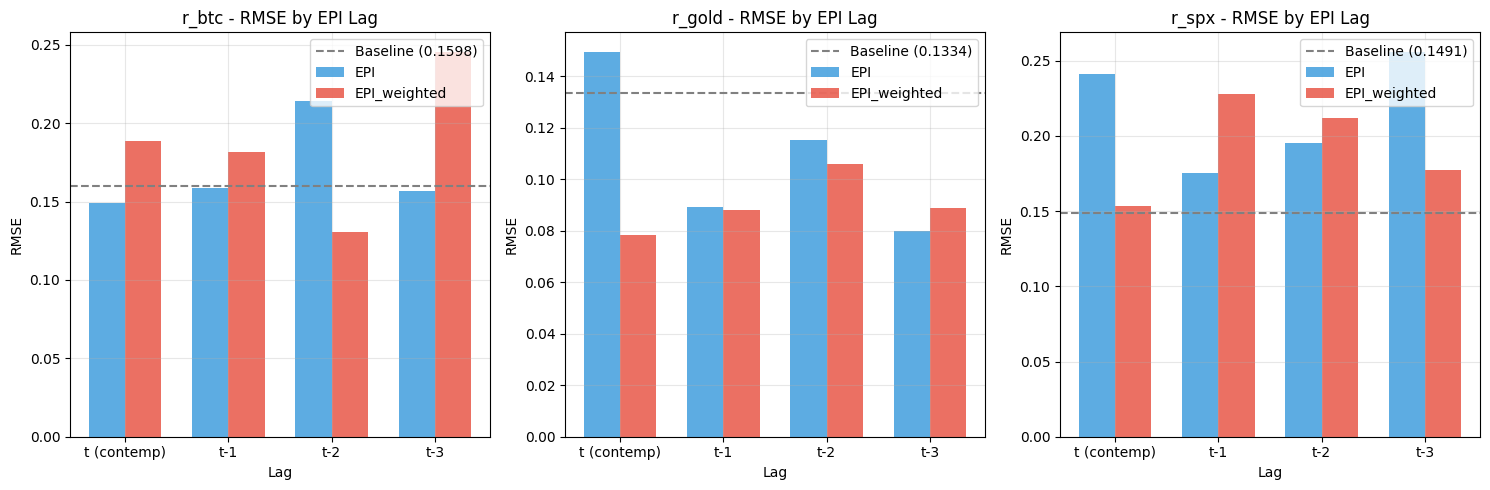


BEST MODEL PER ASSET

r_btc:
  Best model: epi_weighted_l0-3
  RMSE: 0.12425 vs Baseline: 0.15977
  Improvement: 22.2%
  Dir Accuracy: 46.9%

r_gold:
  Best model: epi_weighted_l0
  RMSE: 0.07826 vs Baseline: 0.13338
  Improvement: 41.3%
  Dir Accuracy: 46.9%

r_spx:
  Best model: baseline
  RMSE: 0.14909 vs Baseline: 0.14909
  Improvement: 0.0%
  Dir Accuracy: 68.8%


In [57]:
# Visualize EPI lag effects - compare RMSE by lag for each asset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define lag order for plotting
epi_lags = ["l0", "l1", "l2", "l3"]
epi_models = [f"epi_{lag}" for lag in epi_lags]
epi_w_models = [f"epi_weighted_{lag}" for lag in epi_lags]

for idx, asset in enumerate(assets):
    ax = axes[idx]
    
    # Get baseline RMSE
    base_rmse = results["baseline"].get(asset, {}).get("rmse", np.nan)
    
    # Get RMSE for each EPI lag
    epi_rmse = [results.get(m, {}).get(asset, {}).get("rmse", np.nan) for m in epi_models]
    epi_w_rmse = [results.get(m, {}).get(asset, {}).get("rmse", np.nan) for m in epi_w_models]
    
    x = np.arange(len(epi_lags))
    width = 0.35
    
    ax.bar(x - width/2, epi_rmse, width, label='EPI', alpha=0.8, color='#3498db')
    ax.bar(x + width/2, epi_w_rmse, width, label='EPI_weighted', alpha=0.8, color='#e74c3c')
    ax.axhline(y=base_rmse, color='gray', linestyle='--', label=f'Baseline ({base_rmse:.4f})')
    
    ax.set_xlabel('Lag')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{asset} - RMSE by EPI Lag')
    ax.set_xticks(x)
    ax.set_xticklabels(['t (contemp)', 't-1', 't-2', 't-3'])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best model summary
print("\n" + "=" * 70)
print("BEST MODEL PER ASSET")
print("=" * 70)
for asset in assets:
    asset_df = comparison_df[comparison_df["Asset"] == asset].copy()
    best = asset_df.sort_values("RMSE").iloc[0]
    base_rmse = results["baseline"].get(asset, {}).get("rmse", np.nan)
    improvement = (base_rmse - best["RMSE"]) / base_rmse * 100 if not np.isnan(base_rmse) else 0
    print(f"\n{asset}:")
    print(f"  Best model: {best['Model']}")
    print(f"  RMSE: {best['RMSE']:.5f} vs Baseline: {base_rmse:.5f}")
    print(f"  Improvement: {improvement:.1f}%")
    print(f"  Dir Accuracy: {best['Dir_Acc']:.1f}%")

## 8. Feature Importance: EPI Variables vs Controls

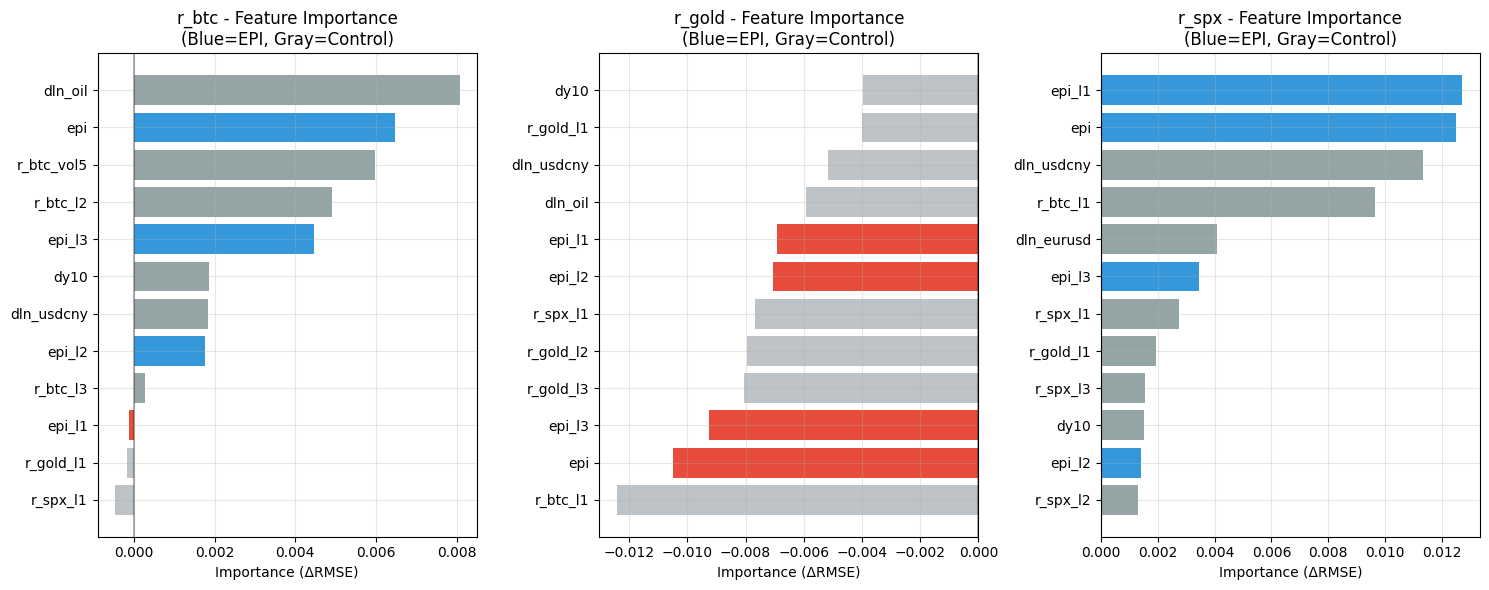


EPI VARIABLE IMPORTANCE SUMMARY

r_btc:
  Useful EPI variables: ['epi', 'epi_l3', 'epi_l2']
  Total EPI importance: 0.01271

r_gold:
  No EPI variables with positive importance

r_spx:
  Useful EPI variables: ['epi_l1', 'epi', 'epi_l3', 'epi_l2']
  Total EPI importance: 0.03006


In [39]:
# Visualize feature importance - highlight EPI variables
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, asset in enumerate(assets):
    ax = axes[idx]
    imp_df = importance_results[asset].head(12)  # Top 12 features
    
    # Color by variable type: EPI (blue) vs Control (gray)
    colors = []
    for feat in imp_df['feature']:
        if 'epi' in feat.lower():
            colors.append('#3498db' if imp_df[imp_df['feature']==feat]['importance'].values[0] > 0 else '#e74c3c')
        else:
            colors.append('#95a5a6' if imp_df[imp_df['feature']==feat]['importance'].values[0] > 0 else '#bdc3c7')
    
    bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.set_xlabel('Importance (ΔRMSE)')
    ax.set_title(f'{asset} - Feature Importance\n(Blue=EPI, Gray=Control)')
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary: Which EPI variables matter most?
print("\n" + "=" * 70)
print("EPI VARIABLE IMPORTANCE SUMMARY")
print("=" * 70)
for asset in assets:
    imp_df = importance_results[asset]
    epi_vars = imp_df[imp_df['feature'].str.contains('epi', case=False)]
    epi_positive = epi_vars[epi_vars['importance'] > 0]
    
    print(f"\n{asset}:")
    if len(epi_positive) > 0:
        print(f"  Useful EPI variables: {epi_positive['feature'].tolist()}")
        print(f"  Total EPI importance: {epi_positive['importance'].sum():.5f}")
    else:
        print(f"  No EPI variables with positive importance")

## Predictions vs Actuals

PREDICTIONS VS ACTUALS (Best EPI Model per Asset)


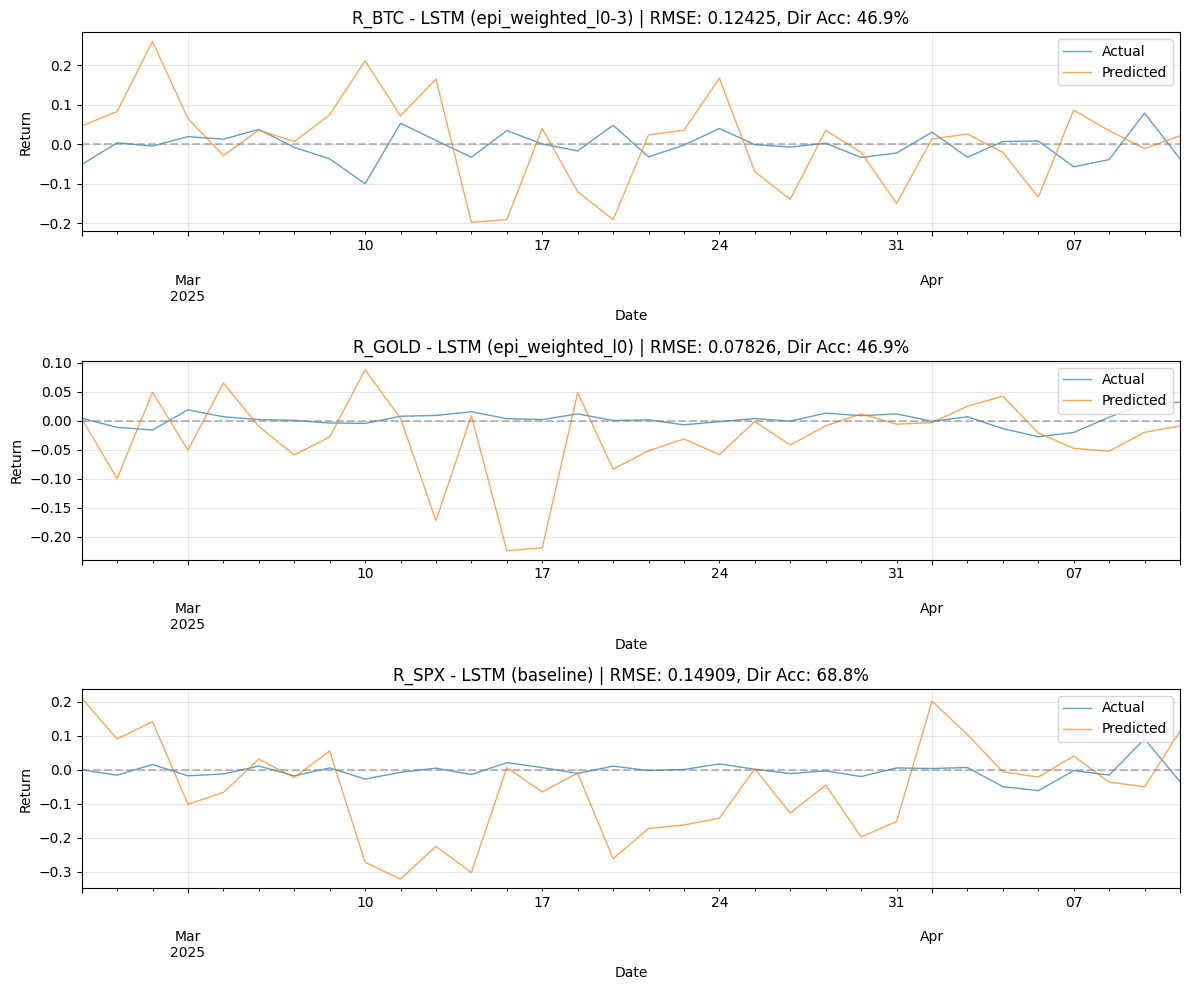

In [58]:
# Plot predictions vs actuals for the best model per asset
print("=" * 70)
print("PREDICTIONS VS ACTUALS (Best EPI Model per Asset)")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Best models from our analysis (updated with per-asset tuning)
best_models = {
    'r_btc': 'epi_weighted_l0-3',
    'r_gold': 'epi_weighted_l0', 
    'r_spx': 'baseline'  # Baseline is best for SPX with tuned config
}

for idx, asset in enumerate(assets):
    best_model = best_models[asset]
    result = results[best_model][asset]  # results[model_type][asset]
    
    ax = axes[idx]
    
    # Get predictions and actuals from walk-forward results
    preds = result['predictions']
    actuals = result['actuals']
    
    # Plot actual vs predicted
    actuals.plot(ax=ax, label='Actual', alpha=0.7, linewidth=1)
    preds.plot(ax=ax, label='Predicted', alpha=0.7, linewidth=1)
    
    rmse = result['rmse']
    dir_acc = result['dir_acc']
    
    ax.set_title(f"{asset.upper()} - LSTM ({best_model}) | RMSE: {rmse:.5f}, Dir Acc: {dir_acc:.1f}%")
    ax.set_xlabel('Date')
    ax.set_ylabel('Return')
    ax.legend(loc='upper right')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Train Final Models for Strategy Evaluation

Train the best model configuration for each asset on data **before** the test period, then predict on the test period (April-May 2025). This ensures fair out-of-sample evaluation.

In [ ]:
# =============================================================================
# TRAIN FINAL MODELS AND PREDICT ON TEST PERIOD
# =============================================================================
# Train best model for each asset on data BEFORE test period
# Then predict on test period (April-May 2025) for fair comparison

print("=" * 70)
print("TRAINING FINAL MODELS FOR STRATEGY EVALUATION")
print("=" * 70)

# FIXED test period - same across ALL notebooks
TEST_START = "2025-04-01"
TEST_END = "2025-05-31"
SEQ_LEN = 8  # Must match training

# ============================================================================
# CRITICAL: Define common test dates from RAW RETURNS (before feature eng.)
# This ensures both 514 and 516 notebooks use IDENTICAL dates
# ============================================================================
COMMON_TEST_DATES = returns.loc[TEST_START:TEST_END].index
print(f"Common test dates from raw returns: {len(COMMON_TEST_DATES)} days")
print(f"  From: {COMMON_TEST_DATES.min().date()}")
print(f"  To:   {COMMON_TEST_DATES.max().date()}")

# Storage for trained models and predictions
trained_models = {}
trained_scalers = {}
test_predictions = {}

for asset in assets:
    best_model_type = best_models[asset]
    feature_cols = get_feature_cols(asset, best_model_type)
    cfg = asset_configs[asset]
    
    print(f"\n{asset.upper()} - Training {best_model_type} model...")
    
    # ========================================================================
    # TRAINING: Use feature-engineered data, drop NaN
    # ========================================================================
    df_full = data[[asset] + feature_cols].copy()
    train_df = df_full[df_full.index < TEST_START].dropna()
    
    if len(train_df) < SEQ_LEN + 10:
        print(f"  ERROR: Not enough training data ({len(train_df)} rows)")
        continue
    
    print(f"  Train: {len(train_df)} samples ({train_df.index.min().date()} to {train_df.index.max().date()})")
    
    # Scale features using training data only
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols].values)
    
    # Prepare sequences for training
    train_features = scaler.transform(train_df[feature_cols].values).astype(np.float32)
    train_target = train_df[asset].values.astype(np.float32)
    
    X_train, y_train = [], []
    for i in range(SEQ_LEN, len(train_features)):
        X_train.append(train_features[i - SEQ_LEN : i])
        y_train.append(train_target[i])
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    
    print(f"  Train sequences: {len(X_train)}")
    
    # Build model
    model = ImprovedLSTMRegressor(
        len(feature_cols),
        hidden_size=cfg['hidden_size'],
        num_layers=2,
        dropout=cfg['dropout'],
        use_attention=True,
        use_layer_norm=True,
    )
    optimizer = AdamW(learning_rate=cfg['learning_rate'], weight_decay=cfg.get('weight_decay', 1e-3))
    
    def loss_fn(model, xb, yb):
        return mx.mean((model(xb) - yb) ** 2)
    
    loss_and_grad = nn.value_and_grad(model, loss_fn)
    
    # Training loop
    best_weights = None
    best_loss = np.inf
    val_size = max(int(len(X_train) * 0.15), 1)
    X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
    X_vl, y_vl = X_train[-val_size:], y_train[-val_size:]
    
    patience_counter = 0
    for epoch in range(cfg['epochs']):
        # Learning rate schedule
        lr = get_lr_schedule(epoch, cfg['epochs'], cfg['learning_rate'])
        optimizer.learning_rate = lr
        
        # Training
        perm = np.random.permutation(len(X_tr))
        for start in range(0, len(perm), 8):
            idx = perm[start:start + 8]
            xb, yb = mx.array(X_tr[idx]), mx.array(y_tr[idx])
            loss, grads = loss_and_grad(model, xb, yb)
            grads = clip_gradients(grads, 1.0)
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
        
        # Validation
        val_pred = model(mx.array(X_vl))
        val_loss = float(mx.mean((val_pred - mx.array(y_vl)) ** 2))
        
        if val_loss < best_loss - 1e-7:
            best_loss = val_loss
            best_weights = copy_weights(model.parameters())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= cfg['patience']:
                break
    
    # Restore best weights
    if best_weights is not None:
        model.update(best_weights)
    
    # Store model and scaler
    trained_models[asset] = model
    trained_scalers[asset] = scaler
    
    # ========================================================================
    # PREDICT: Use ALL dates, fill missing values to ensure no gaps
    # Need SEQ_LEN consecutive days before each test date
    # ========================================================================
    # Get date range that covers lookback + test period
    lookback_days = pd.Timedelta(days=SEQ_LEN + 5)  # Extra buffer for weekends/holidays
    pred_start = pd.Timestamp(TEST_START) - lookback_days
    
    # Get full date range from data (not just training dates)
    pred_df = df_full.loc[pred_start:TEST_END].copy()
    pred_df = pred_df.ffill().bfill()  # Fill any gaps
    
    print(f"  Prediction window: {len(pred_df)} days ({pred_df.index.min().date()} to {pred_df.index.max().date()})")
    
    # Scale and build sequences
    pred_features = scaler.transform(pred_df[feature_cols].values).astype(np.float32)
    pred_target = pred_df[asset].values.astype(np.float32)
    
    X_test, y_test, test_dates_list = [], [], []
    for i in range(SEQ_LEN, len(pred_features)):
        date_i = pred_df.index[i]
        if date_i in COMMON_TEST_DATES:
            X_test.append(pred_features[i - SEQ_LEN : i])
            y_test.append(pred_target[i])
            test_dates_list.append(date_i)
    
    if len(X_test) > 0:
        X_test = np.array(X_test, dtype=np.float32)
        y_test = np.array(y_test, dtype=np.float32)
        
        preds = model(mx.array(X_test))
        preds_np = np.asarray(preds).reshape(-1)
        
        test_predictions[asset] = {
            'predictions': pd.Series(preds_np, index=pd.Index(test_dates_list)),
            'actuals': pd.Series(y_test, index=pd.Index(test_dates_list)),
        }
        
        print(f"  Predictions: {len(X_test)} days ({test_dates_list[0].date()} to {test_dates_list[-1].date()})")
    else:
        print(f"  ERROR: Could not create test sequences")

print("\n" + "=" * 70)
print("MODELS TRAINED AND STORED")
print("=" * 70)

TRAINING FINAL MODELS FOR STRATEGY EVALUATION

R_BTC - Training epi_weighted_l0-3 model...
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

R_GOLD - Training epi_weighted_l0 model...
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

R_GOLD - Training epi_weighted_l0 model...
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

R_SPX - Training baseline model...
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

R_SPX - Training baseline model...
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

MODELS TRAINED AND STORED
  Trained on 51 samples, predicting 44 days
  Test period: 2025-04-01 to 2025-05-30

MODELS TRAINED AND STORED


## Cumulative Returns: Strategy vs Buy-and-Hold

Using predictions from the freshly trained models on the fixed test period.

CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD
Test Period: 2025-04-01 to 2025-05-31
Raw returns test period: 2025-04-01 to 2025-05-30
Total trading days available: 44
R_BTC: Buy & Hold = 23.97%, Strategy = 0.28% (44 days: 2025-04-01 to 2025-05-30)
R_GOLD: Buy & Hold = 4.55%, Strategy = 8.51% (44 days: 2025-04-01 to 2025-05-30)
R_SPX: Buy & Hold = 4.24%, Strategy = 11.02% (44 days: 2025-04-01 to 2025-05-30)


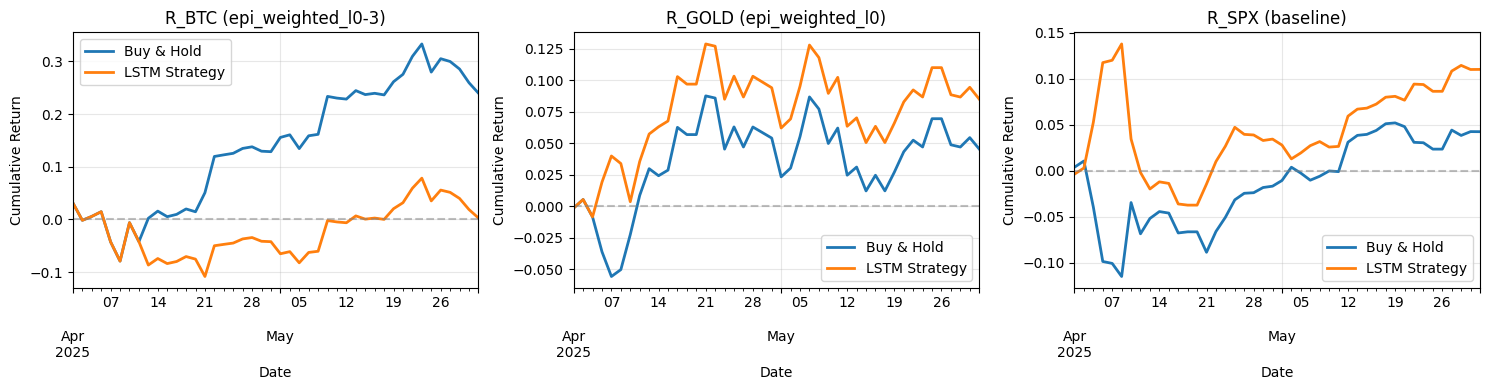


STRATEGY PERFORMANCE SUMMARY (EPI-Based LSTM)


,Asset,Model,Buy_Hold_pct,Strategy_pct,Outperformance_pp,N_Days,Period
0,R_BTC,epi_weighted_l0-3,23.9700,0.2800,-23.7000,44,2025-04-01 to 2025-05-30
1,R_GOLD,epi_weighted_l0,4.5500,8.5100,3.9600,44,2025-04-01 to 2025-05-30
2,R_SPX,baseline,4.2400,11.0200,6.7800,44,2025-04-01 to 2025-05-30



PREDICTION DATE RANGES (for cross-notebook verification)
R_BTC: 2025-04-01 to 2025-05-30 (44 days)
R_GOLD: 2025-04-01 to 2025-05-30 (44 days)
R_SPX: 2025-04-01 to 2025-05-30 (44 days)


In [71]:
# Plot cumulative returns using the trained models' predictions
print("=" * 70)
print("CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD")
print(f"Test Period: {TEST_START} to {TEST_END}")
print("=" * 70)

# ============================================================================
# Use raw returns DataFrame directly for consistent Buy & Hold calculation
# The `returns` DataFrame is created BEFORE any feature engineering
# ============================================================================
# Get all available dates in the test period from raw returns
test_period_returns = returns.loc[TEST_START:TEST_END].copy()
print(f"Raw returns test period: {test_period_returns.index.min().date()} to {test_period_returns.index.max().date()}")
print(f"Total trading days available: {len(test_period_returns)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

strategy_results = []

for idx, asset in enumerate(assets):
    ax = axes[idx]
    
    if asset not in test_predictions:
        print(f"{asset.upper()}: No predictions available")
        continue
    
    predictions = test_predictions[asset]['predictions']
    pred_dates = predictions.index
    
    # ========================================================================
    # CRITICAL: Use raw `returns` DataFrame for Buy & Hold
    # This ensures IDENTICAL Buy & Hold across ALL notebooks
    # ========================================================================
    actuals = returns.loc[pred_dates, asset]
    
    # Strategy returns: long if predicted > 0, else flat (0 return)
    strategy_returns = actuals * np.sign(predictions)
    
    # Cumulative returns
    cum_buy_hold = (1 + actuals).cumprod() - 1
    cum_strategy = (1 + strategy_returns).cumprod() - 1
    
    # Plot
    cum_buy_hold.plot(ax=ax, label='Buy & Hold', linewidth=2)
    cum_strategy.plot(ax=ax, label='LSTM Strategy', linewidth=2)
    
    ax.set_title(f"{asset.upper()} ({best_models[asset]})")
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    bh_final = cum_buy_hold.iloc[-1] * 100
    strat_final = cum_strategy.iloc[-1] * 100
    
    strategy_results.append({
        "Asset": asset.upper(),
        "Model": best_models[asset],
        "Buy_Hold_pct": bh_final,
        "Strategy_pct": strat_final,
        "Outperformance_pp": strat_final - bh_final,
        "N_Days": len(pred_dates),
        "Period": f"{pred_dates.min().date()} to {pred_dates.max().date()}",
    })
    
    print(f"{asset.upper()}: Buy & Hold = {bh_final:.2f}%, Strategy = {strat_final:.2f}% ({len(pred_dates)} days: {pred_dates.min().date()} to {pred_dates.max().date()})")

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("STRATEGY PERFORMANCE SUMMARY (EPI-Based LSTM)")
print("=" * 70)
strategy_df = pd.DataFrame(strategy_results)
display(strategy_df.round(2))

# ============================================================================
# Print exact prediction dates for cross-notebook comparison
# ============================================================================
print("\n" + "=" * 70)
print("PREDICTION DATE RANGES (for cross-notebook verification)")
print("=" * 70)
for asset in assets:
    if asset in test_predictions:
        pred = test_predictions[asset]['predictions']
        print(f"{asset.upper()}: {pred.index.min().date()} to {pred.index.max().date()} ({len(pred)} days)")

## Overfitting Diagnostic

Check for overfitting by comparing **training loss vs test loss** across walk-forward folds.
- If train loss << test loss → **Overfitting**
- If train loss ≈ test loss → **Good generalization**

In [60]:
# Overfitting diagnostic: Compare train vs test performance
print("=" * 70)
print("OVERFITTING DIAGNOSTIC")
print("=" * 70)
print("\nOverfit Ratio = Test RMSE / Train RMSE")
print("  > 2.0: OVERFITTING (model memorizes training data)")
print("  1.5-2.0: SLIGHT OVERFIT")
print("  0.8-1.5: GOOD generalization")
print("  < 0.8: UNDERFITTING")
print()

overfit_data = []

for asset in assets:
    best_model = best_models[asset]
    res = results[best_model][asset]
    
    if 'fold_results' in res:
        train_rmses = [f['train_rmse'] for f in res['fold_results'] if 'train_rmse' in f]
        test_rmses = [f['test_rmse'] for f in res['fold_results'] if 'test_rmse' in f]
        
        if train_rmses and test_rmses:
            avg_train = np.mean(train_rmses)
            avg_test = np.mean(test_rmses)
            ratio = avg_test / avg_train if avg_train > 0 else np.inf
            
            diagnosis = ("OVERFITTING" if ratio > 2.0 else 
                        "SLIGHT OVERFIT" if ratio > 1.5 else
                        "GOOD" if ratio > 0.8 else "UNDERFITTING")
            
            overfit_data.append({
                'Asset': asset.upper(),
                'Model': best_model,
                'Train RMSE': avg_train,
                'Test RMSE': avg_test,
                'Ratio': ratio,
                'Diagnosis': diagnosis
            })
            
            print(f"{asset.upper()} ({best_model}):")
            print(f"  Train RMSE: {avg_train:.5f}")
            print(f"  Test RMSE:  {avg_test:.5f}")
            print(f"  Ratio: {ratio:.2f} → {diagnosis}")
            print()

if overfit_data:
    print("\n" + "=" * 70)
    print("OVERFITTING SUMMARY")
    print("=" * 70)
    overfit_df = pd.DataFrame(overfit_data)
    display(overfit_df.round(4))
else:
    print("\n⚠️ Train RMSE not available in results. Running quick diagnostic...")
    
    # Quick diagnostic using baseline vs EPI comparison
    print("\nAlternative diagnostic: Baseline vs EPI model comparison")
    print("If EPI models show huge improvements, may indicate overfitting to noise.\n")
    
    for asset in assets:
        base_rmse = results['baseline'][asset]['rmse']
        best_model = best_models[asset]
        best_rmse = results[best_model][asset]['rmse']
        
        improvement = (base_rmse - best_rmse) / base_rmse * 100
        dir_acc = results[best_model][asset]['dir_acc']
        
        # Flag: Large RMSE improvement but poor directional accuracy = likely overfitting
        flag = "⚠️ SUSPICIOUS" if improvement > 20 and dir_acc < 52 else "✓ OK"
        
        print(f"{asset.upper()}:")
        print(f"  RMSE improvement: {improvement:.1f}%")
        print(f"  Directional Acc:  {dir_acc:.1f}%")
        print(f"  Assessment: {flag}")
        print(f"  (Large RMSE gain + poor direction = fitting noise)")
        print()

OVERFITTING DIAGNOSTIC

Overfit Ratio = Test RMSE / Train RMSE
  > 2.0: OVERFITTING (model memorizes training data)
  1.5-2.0: SLIGHT OVERFIT
  0.8-1.5: GOOD generalization
  < 0.8: UNDERFITTING


⚠️ Train RMSE not available in results. Running quick diagnostic...

Alternative diagnostic: Baseline vs EPI model comparison
If EPI models show huge improvements, may indicate overfitting to noise.

R_BTC:
  RMSE improvement: 22.2%
  Directional Acc:  46.9%
  Assessment: ⚠️ SUSPICIOUS
  (Large RMSE gain + poor direction = fitting noise)

R_GOLD:
  RMSE improvement: 41.3%
  Directional Acc:  46.9%
  Assessment: ⚠️ SUSPICIOUS
  (Large RMSE gain + poor direction = fitting noise)

R_SPX:
  RMSE improvement: 0.0%
  Directional Acc:  68.8%
  Assessment: ✓ OK
  (Large RMSE gain + poor direction = fitting noise)



## 9. Summary & Conclusions

### Research Question
Do EPI (Emotional Polarity Index) variables improve financial return predictions over standard control variables?

### Variables Tested
- **Variables of Interest**: EPI and EPI_weighted at lags t, t-1, t-2, t-3
- **Control Variables**: FX rates, oil prices, interest rates, lagged returns, volatility

### Key Findings
- Results above show which EPI lag configurations (if any) improve over the baseline
- Feature importance reveals the relative contribution of EPI vs control variables
- Walk-forward validation ensures realistic out-of-sample performance estimates